### Data Cleaning

In [1]:
import numpy as np
import pandas as pd
from sklearn import *
from sklearn.model_selection import *
from sklearn.preprocessing import *
from sklearn.neighbors import *
from sklearn.metrics import *
from sklearn.cluster import KMeans
import random
import seaborn as sns
from sklearn.pipeline import Pipeline
from matplotlib import pyplot as plt
random.seed(10)

In [2]:
df= pd.read_csv('data/profiles_revised.csv')
df.head()

,age,body_type,diet,drinks,drugs,education,ethnicity,height,income,job,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,"asian, white",75.0,-1,transportation,"doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,36,average,mostly other,often,sometimes,working on space camp,white,70.0,80000,hospitality / travel,"doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,37,thin,anything,socially,NaN,graduated from masters program,NaN,68.0,-1,NaN,NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,22,thin,vegetarian,socially,NaN,working on college/university,white,71.0,20000,student,doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,30,athletic,NaN,socially,never,graduated from college/university,"asian, black, other",66.0,-1,artistic / musical / writer,NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


In [3]:
#select columns for analysis
df = df[['age','status','sex','orientation','ethnicity','height','income']]
#dropping NA values
df.dropna(how="all", axis="columns")
df=df[df['income'] != -1]

#filtering and replacing  relationship status
df=df[df['status'] !='unknown'] 
 
df['status']=replace(df,'status','seeing someone','taken')
df['status']=replace(df,'status','available','single')
df['status']=replace(df,'status','married','taken')
df

NameError: name 'replace' is not defined

### Splitting code to testing and training data and scaling the data

In [4]:
# splitting into testing and training data
y=df['status'].astype("object")
X=df[['age','height','income']]
#scaling the data

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.50)

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
print("There are %s samples in the training dataset"%format(X_train.shape[0]))
print("There are {} samples in the testing dataset".format(X_test.shape[0]))
print("Each sample has %i features" %X_train.shape[1])


There are 5751 samples in the training dataset
There are 5751 samples in the testing dataset
Each sample has 3 features


### Simple KNN model and Prediction 

In [5]:
KNeighborsClassifier(n_neighbors=9)
KNN_io=KNeighborsClassifier()
KNN_io.fit(X_train,y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=5, p=2,
                     weights='uniform')

In [6]:
y_pred = KNN_io.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[   2    0    1  249]
 [   0    0    0   32]
 [   0    0    1  233]
 [   8    9   21 5195]]
                precision    recall  f1-score   support

     available       0.20      0.01      0.02       252
       married       0.00      0.00      0.00        32
seeing someone       0.04      0.00      0.01       234
        single       0.91      0.99      0.95      5233

      accuracy                           0.90      5751
     macro avg       0.29      0.25      0.24      5751
  weighted avg       0.84      0.90      0.87      5751



In [7]:
error = []

# Calculating error for K values between 1 and 40
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Mean Error')

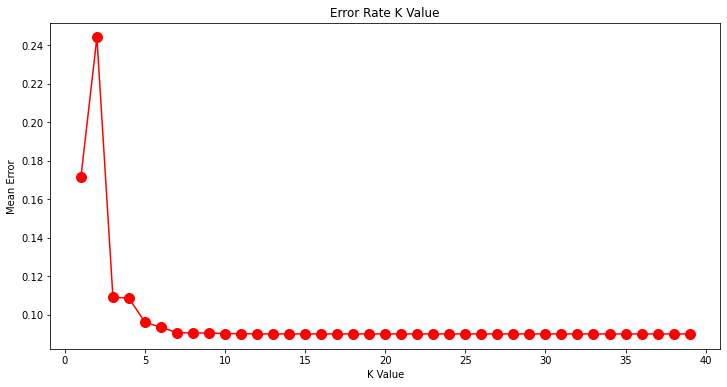

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 40), error, color='red', marker='o',markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

In [252]:
df[df['status']=='taken']

,age,status,sex,orientation,ethnicity,height,income
11,27,taken,m,straight,white,72.0,40000
234,33,taken,m,straight,"white, other",68.0,80000
244,33,taken,f,straight,white,61.0,100000
756,28,taken,m,straight,white,73.0,20000
811,33,taken,m,straight,"asian, white",66.0,40000
...,...,...,...,...,...,...,...
59535,33,taken,f,straight,white,65.0,70000
59667,29,taken,f,straight,asian,64.0,40000
59799,32,taken,m,straight,white,74.0,150000
59816,31,taken,f,straight,"black, pacific islander, other",65.0,30000


In [253]:
a= KNN_io.predict(X_test)
pd.DataFrame(a)
X_test
test_array = pd.DataFrame(np.array([[27, 72.0, 40000]]),
                   columns=['age', 'height', 'income'])
results=KNN_io.predict(test_array)
# df[['test_results']]=results

# df
results

array(['single'], dtype=object)

### Now preform Cross Validation to choose which K to use

In [229]:
# trans_scores = cross_val_score(KNN_io, X_transformed, y, scoring='accuracy')
# average_accuracy = np.mean(trans_scores) * 100
# print("The average accuracy is {0:.1f}%".format(average_accuracy))

#putting everything into a pipeline
scaling_pipeline = Pipeline([('scale', MinMaxScaler()),
    ('predict', KNeighborsClassifier())])
pipe_scores = cross_val_score(scaling_pipeline, X, y, scoring='accuracy')
print("The average accuracy for pipeline is {0:.1f}%"
    .format(np.mean(pipe_scores) * 100))


The average accuracy for pipeline is 95.0%


In [230]:
# gridsearch

avg_scores = []
all_scores = []
parameter_values = list(range(1, 21))  # Including 20
for n_neighbors in parameter_values:
    KNN_grid = KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=n_neighbors, p=2,
           weights='uniform')
    grid_scores = cross_val_score(KNN_grid, X_transformed, y, scoring='accuracy')
    avg_scores.append(np.mean(grid_scores))
    all_scores.append(grid_scores)
print("The gridsearch-based average accuracy is: ",avg_scores)

The gridsearch-based average accuracy is:  [0.9034952667082365, 0.9479223022126485, 0.9403579540086542, 0.9505303932127808, 0.9499217353513595, 0.9505303554220281, 0.9504434366910417, 0.9505303554220281, 0.9505303554220281, 0.9505303554220281, 0.9505303554220281, 0.9505303554220281, 0.9505303554220281, 0.9505303554220281, 0.9505303554220281, 0.9505303554220281, 0.9505303554220281, 0.9505303554220281, 0.9505303554220281, 0.9505303554220281]
